In [2]:
# This code is implemented by Chauby (chaubyZou@163.com), feel free to use it.
# the repository of this code is: https://github.com/chauby/ZMP_preview_control.git


#%% Initialize global variations
import numpy as np
from control.matlab import dare # for solving the discrete algebraic Riccati equation


In [3]:
# ------------------------------- Preview Control, reference: 2003-Biped Walking Pattern Generation by Using Preview Control of Zero-moment Point
def calculatePreviewControlParams(A, B, C, Q, R, N):
    [P, _, _] = dare(A, B, C.T*Q*C, R)
    K = (R + B.T*P*B).I*(B.T*P*A)

    f = np.zeros((1, N))
    for i in range(N):
        f[0,i] = (R+B.T*P*B).I*B.T*(((A-B*K).T)**i)*C.T*Q

    return K, f

# ------------------------------- Improved Preview Control, reference: 2007-General ZMP Preview Control for Bipedal Walking
def calculatePreviewControlParams2(A, B, C, Q, R, N):
    C_dot_A = C*A
    C_dot_B = C*B

    A_tilde = np.matrix([[1, C_dot_A[0,0], C_dot_A[0,1], C_dot_A[0,2]],
                            [0, A[0,0], A[0,1], A[0,2]],
                            [0, A[1,0], A[1,1], A[1,2]],
                            [0, A[2,0], A[2,1], A[2,2]]])
    B_tilde = np.matrix([[C_dot_B[0,0]],
                            [B[0,0]],
                            [B[1,0]],
                            [B[2,0]]])
    C_tilde = np.matrix([[1, 0, 0, 0]])

    [P_tilde, _, _] = dare(A_tilde, B_tilde, C_tilde.T*Q*C_tilde, R)
    K_tilde = (R + B_tilde.T*P_tilde*B_tilde).I*(B_tilde.T*P_tilde*A_tilde)

    Ks = K_tilde[0, 0]
    Kx = K_tilde[0, 1:]

    Ac_tilde = A_tilde - B_tilde*K_tilde

    G = np.zeros((1, N))

    G[0] = -Ks
    I_tilde = np.matrix([[1],[0],[0],[0]])
    X_tilde = -Ac_tilde.T*P_tilde*I_tilde

    for i in range(N):
        G[0,i] = (R + B_tilde.T*P_tilde*B_tilde).I*(B_tilde.T)*X_tilde
        X_tilde = Ac_tilde.T*X_tilde

    return Ks, Kx, G



### Continuous-time model (LIPM with jerk input)

For one horizontal axis (use the same for x and y), define the CoM state

$$
\mathbf{x}(t)=
\begin{bmatrix}
c(t)\\
\dot c(t)\\
\ddot c(t)
\end{bmatrix},
\qquad
u(t)=\dddot c(t).
$$

Then the continuous-time dynamics are

$$
\dot{\mathbf{x}}(t)=A_c\,\mathbf{x}(t)+B_c\,u(t),
$$

with

$$
A_c=
\begin{bmatrix}
0&1&0\\
0&0&1\\
0&0&0
\end{bmatrix},
\qquad
B_c=
\begin{bmatrix}
0\\
0\\
1
\end{bmatrix}.
$$

The ZMP output under constant CoM height $z_c$ (LIPM) is

$$
p(t)=c(t)-\frac{z_c}{g}\ddot c(t)
\;=\;
C\,\mathbf{x}(t),
\qquad
C=\begin{bmatrix}1&0&-\tfrac{z_c}{g}\end{bmatrix}.
$$


---

### Discrete-time dynamics (ZOH discretization)

Assume a sample time $T$ (your `dt`) and a zero-order hold (ZOH) input:

$$
u(t)=u_k,\quad t\in[kT,(k+1)T).
$$

Then the discrete-time system

$$
\mathbf{x}_{k+1}=A\,\mathbf{x}_k+B\,u_k
$$

is obtained from the continuous-to-discrete formulas

$$
A = e^{A_c T},\qquad
B = \int_0^T e^{A_c \tau}\,B_c\,d\tau.
$$



Here $A_c$ is nilpotent ($A_c^3=0$), so the matrix exponential truncates:

$$
e^{A_cT}=I + A_cT + \frac{A_c^2T^2}{2}.
$$

Since

$$
A_c=
\begin{bmatrix}
0&1&0\\
0&0&1\\
0&0&0
\end{bmatrix},
\quad
A_c^2=
\begin{bmatrix}
0&0&1\\
0&0&0\\
0&0&0
\end{bmatrix},
$$

you get

$$
A=
\begin{bmatrix}
1 & T & \tfrac{T^2}{2}\\
0 & 1 & T\\
0 & 0 & 1
\end{bmatrix}.
$$


First,

$$
e^{A_c\tau}B_c
=
\left(I + A_c\tau + \frac{A_c^2\tau^2}{2}\right)
\begin{bmatrix}0\\0\\1\end{bmatrix}
=
\begin{bmatrix}
\tfrac{\tau^2}{2}\\
\tau\\
1
\end{bmatrix}.
$$

Then integrate from $0$ to $T$:

$$
B=
\int_0^T
\begin{bmatrix}
\tfrac{\tau^2}{2}\\
\tau\\
1
\end{bmatrix}
d\tau
=
\begin{bmatrix}
\tfrac{T^3}{6}\\
\tfrac{T^2}{2}\\
T
\end{bmatrix}.
$$


$$
\mathbf{x}_{k+1}=
\begin{bmatrix}
1 & T & \tfrac{T^2}{2}\\
0 & 1 & T\\
0 & 0 & 1
\end{bmatrix}\mathbf{x}_k
+
\begin{bmatrix}
\tfrac{T^3}{6}\\
\tfrac{T^2}{2}\\
T
\end{bmatrix}u_k,
\qquad
p_k=C\mathbf{x}_k.
$$


### 2D version (apply to \(x\) and \(y\) independently)

$$
\mathbf{x}^x_{k+1}=A\mathbf{x}^x_k+B u^x_k,\quad p^x_k=C\mathbf{x}^x_k
$$

$$
\mathbf{x}^y_{k+1}=A\mathbf{x}^y_k+B u^y_k,\quad p^y_k=C\mathbf{x}^y_k
$$


In [4]:
step_pos = np.array([[0, 0.0],
                    [0.2, 0.06],
                    [0.4, -0.06],
                    [0.6, 0.09],
                    [0.8, -0.03],
                    [1.3, 0.09],
                    [1.7, -0.03],
                    [1.9, 0.09],
                    [2.0, -0.03]])
z_c = 0.5
g = 9.81
dt = 0.01
t_step = 0.7 # timing for one step
t_preview = 1.0 # timing for preview
n_step = len(step_pos)
t_simulation = n_step*t_step - t_preview - dt # timing for simulation

N_preview = int(t_preview/dt) # preview length
N_simulation = int(t_simulation/dt)

# Generate ZMP trajectory
ZMP_x_ref = []
ZMP_y_ref = []
i = 0
for t in  np.arange(0, n_step*t_step, dt):
    ZMP_x_ref.append(step_pos[i,0])
    ZMP_y_ref.append(step_pos[i,1])

    if (t != 0) and (t%t_step < 1e-6):
        i += 1


# Define basic matrix

A = np.asmatrix(([1, dt, dt**2/2],
            [0, 1, dt],
            [0, 0, 1]))
B = np.asmatrix((dt**3/6, dt**2/2, dt)).T
C = np.asmatrix((1, 0, -z_c/g))

Q = 1
R = 1e-6

# Calculate Preview control parameters
K, f = calculatePreviewControlParams(A, B, C, Q, R, N_preview)

# Calculate Improved Preview control parameters
Ks, Kx, G = calculatePreviewControlParams2(A, B, C, Q, R, N_preview)


# ------------------------------- for Preview Control
ux_1 = np.asmatrix(np.zeros((N_simulation, 1)))
uy_1 = np.asmatrix(np.zeros((N_simulation, 1)))
COM_x_1 = np.asmatrix(np.zeros((3, N_simulation+1)))
COM_y_1 = np.asmatrix(np.zeros((3, N_simulation+1)))

# record data for plot
COM_x_record_1 = []
COM_y_record_1 = []
ZMP_x_record_1 = []
ZMP_y_record_1 = []

# ------------------------------- for Improved Preview Control 1
ux_2 = np.asmatrix(np.zeros((N_simulation, 1)))
uy_2 = np.asmatrix(np.zeros((N_simulation, 1)))
COM_x_2 = np.asmatrix(np.zeros((3, N_simulation+1)))
COM_y_2 = np.asmatrix(np.zeros((3, N_simulation+1)))

# record data for plot
COM_x_record_2 = []
COM_y_record_2 = []
ZMP_x_record_2 = []
ZMP_y_record_2 = []

e_x_2 = np.zeros((N_simulation, 1))
e_y_2 = np.zeros((N_simulation, 1))


# ------------------------------- for Improved Preview Control 2
ux_3 = np.asmatrix(np.zeros((N_simulation, 1)))
uy_3 = np.asmatrix(np.zeros((N_simulation, 1)))
COM_x_3 = np.asmatrix(np.zeros((3, N_simulation+1)))
COM_y_3 = np.asmatrix(np.zeros((3, N_simulation+1)))

# record data for plot
COM_x_record_3 = []
COM_y_record_3 = []
ZMP_x_record_3 = []
ZMP_y_record_3 = []

e_x_3 = np.zeros((N_simulation, 1))
e_y_3 = np.zeros((N_simulation, 1))

sum_e_x = 0
sum_e_y = 0


# main loop
for k in range(N_simulation):
    ZMP_x_preview = np.asmatrix(ZMP_x_ref[k:k+N_preview]).T
    ZMP_y_preview = np.asmatrix(ZMP_y_ref[k:k+N_preview]).T

    # ------------------------------- 1: Preview Control
    # update ZMP
    ZMP_x = C*COM_x_1[:,k]
    ZMP_y = C*COM_y_1[:,k]
    ZMP_x_record_1.append(ZMP_x[0,0])
    ZMP_y_record_1.append(ZMP_y[0,0])

    # update u
    ux_1[k] = -K*COM_x_1[:, k] + f*ZMP_x_preview
    uy_1[k] = -K*COM_y_1[:, k] + f*ZMP_y_preview

    # update COM state
    COM_x_1[:,k+1] = A*COM_x_1[:, k] + B*ux_1[k]
    COM_y_1[:,k+1] = A*COM_y_1[:, k] + B*uy_1[k]
    COM_x_record_1.append(COM_x_1[0,k])
    COM_y_record_1.append(COM_y_1[0,k])


    # -------------------------------- 2: Improved Preview Control with only current error
    # update ZMP
    ZMP_x = C*COM_x_2[:,k]
    ZMP_y = C*COM_y_2[:,k]
    ZMP_x_record_2.append(ZMP_x[0,0])
    ZMP_y_record_2.append(ZMP_y[0,0])

    # calculate errors
    e_x_2[k] = ZMP_x_ref[k] - ZMP_x
    e_y_2[k] = ZMP_y_ref[k] - ZMP_y

    # update u
    ux_2[k] = -Ks*e_x_2[k] - Kx*COM_x_2[:, k] - G*ZMP_x_preview
    uy_2[k] = -Ks*e_y_2[k] - Kx*COM_y_2[:, k] - G*ZMP_y_preview

    # update COM state
    COM_x_2[:,k+1] = A*COM_x_2[:, k] + B*ux_2[k]
    COM_y_2[:,k+1] = A*COM_y_2[:, k] + B*uy_2[k]
    COM_x_record_2.append(COM_x_2[0,k])
    COM_y_record_2.append(COM_y_2[0,k])

    # --------------------------------- 3: Improved Preview Control with the summary of history errors
    # update ZMP
    ZMP_x = C*COM_x_3[:,k]
    ZMP_y = C*COM_y_3[:,k]
    ZMP_x_record_3.append(ZMP_x[0,0])
    ZMP_y_record_3.append(ZMP_y[0,0])

    # calculate errors
    e_x_3[k] = ZMP_x - ZMP_x_ref[k] 
    e_y_3[k] = ZMP_y - ZMP_y_ref[k]
    sum_e_x += e_x_3[k]
    sum_e_y += e_y_3[k]

    # update u
    ux_3[k] = -Ks*sum_e_x - Kx*COM_x_3[:, k] - G*ZMP_x_preview
    uy_3[k] = -Ks*sum_e_y - Kx*COM_y_3[:, k] - G*ZMP_y_preview

    # update COM state
    COM_x_3[:,k+1] = A*COM_x_3[:, k] + B*ux_3[k]
    COM_y_3[:,k+1] = A*COM_y_3[:, k] + B*uy_3[k]
    COM_x_record_3.append(COM_x_3[0,k])
    COM_y_record_3.append(COM_y_3[0,k])


/tmp/ipykernel_21980/4046272303.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f[0,i] = (R+B.T*P*B).I*B.T*(((A-B*K).T)**i)*C.T*Q
/tmp/ipykernel_21980/4046272303.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  G[0,i] = (R + B_tilde.T*P_tilde*B_tilde).I*(B_tilde.T)*X_tilde


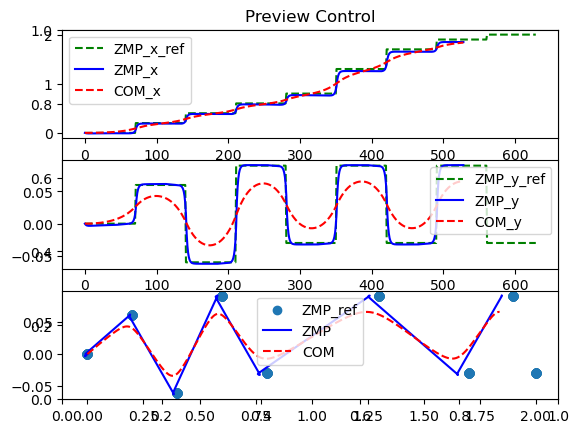

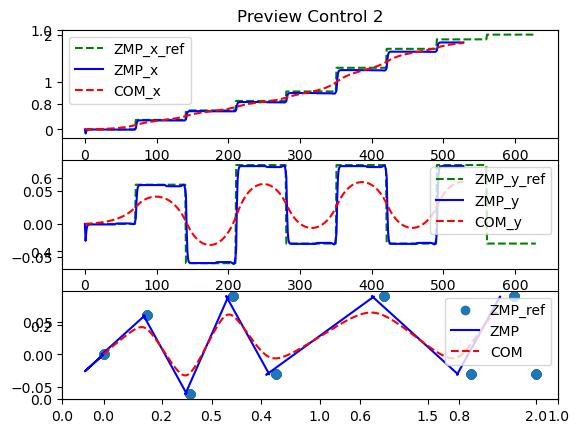

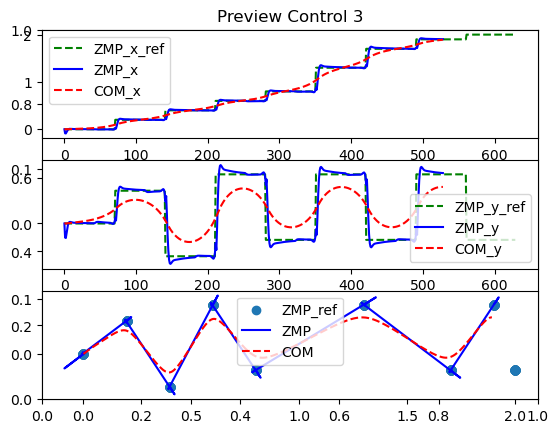

In [6]:
  # plot
import matplotlib.pyplot as plt
plt.figure()
plt.title("Preview Control")
plt.subplot(3,1,1)
plt.plot(ZMP_x_ref, 'g--', label='ZMP_x_ref')
plt.plot(ZMP_x_record_1, 'b', label='ZMP_x')
plt.plot(COM_x_record_1, 'r--', label='COM_x')
plt.legend()
plt.subplot(3,1,2)
plt.plot(ZMP_y_ref, 'g--', label='ZMP_y_ref')
plt.plot(ZMP_y_record_1, 'b', label='ZMP_y')
plt.plot(COM_y_record_1, 'r--', label='COM_y')
plt.legend()
plt.subplot(3,1,3)
plt.scatter(ZMP_x_ref, ZMP_y_ref, label='ZMP_ref')
plt.plot(ZMP_x_record_1, ZMP_y_record_1, 'b', label='ZMP')
plt.plot(COM_x_record_1, COM_y_record_1, 'r--', label='COM')
plt.legend()

plt.figure()
plt.title("Preview Control 2")
plt.subplot(3,1,1)
plt.plot(ZMP_x_ref, 'g--', label='ZMP_x_ref')
plt.plot(ZMP_x_record_2, 'b', label='ZMP_x')
plt.plot(COM_x_record_2, 'r--', label='COM_x')
plt.legend()
plt.subplot(3,1,2)
plt.plot(ZMP_y_ref, 'g--', label='ZMP_y_ref')
plt.plot(ZMP_y_record_2, 'b', label='ZMP_y')
plt.plot(COM_y_record_2, 'r--', label='COM_y')
plt.legend()
plt.subplot(3,1,3)
plt.scatter(ZMP_x_ref, ZMP_y_ref, label='ZMP_ref')
plt.plot(ZMP_x_record_2, ZMP_y_record_2, 'b', label='ZMP')
plt.plot(COM_x_record_2, COM_y_record_2, 'r--', label='COM')
plt.legend()

plt.figure()
plt.title("Preview Control 3")
plt.subplot(3,1,1)
plt.plot(ZMP_x_ref, 'g--', label='ZMP_x_ref')
plt.plot(ZMP_x_record_3, 'b', label='ZMP_x')
plt.plot(COM_x_record_3, 'r--', label='COM_x')
plt.legend()
plt.subplot(3,1,2)
plt.plot(ZMP_y_ref, 'g--', label='ZMP_y_ref')
plt.plot(ZMP_y_record_3, 'b', label='ZMP_y')
plt.plot(COM_y_record_3, 'r--', label='COM_y')
plt.legend()
plt.subplot(3,1,3)
plt.scatter(ZMP_x_ref, ZMP_y_ref, label='ZMP_ref')
plt.plot(ZMP_x_record_3, ZMP_y_record_3, 'b', label='ZMP')
plt.plot(COM_x_record_3, COM_y_record_3, 'r--', label='COM')
plt.legend()

plt.show()
